# Digit Recognition from Scratch using Neural Network
### Dataset: MNIST via PyTorch `torchvision`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import torchvision
import torchvision.transforms as transforms

## 1. Load MNIST via PyTorch

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                      # PIL Image -> Tensor, scales to [0, 1]
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST global mean & std
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Convert to numpy for our from-scratch network
X_train = train_dataset.data.numpy().reshape(-1, 784) / 255.0
y_train = train_dataset.targets.numpy()
X_test  = test_dataset.data.numpy().reshape(-1, 784)  / 255.0
y_test  = test_dataset.targets.numpy()

print(f"Train samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")
print(f"Features      : {X_train.shape[1]} (28x28 pixels flattened)")
print(f"Classes       : {np.unique(y_train)}")

100.0%
100.0%
100.0%
100.0%


Train samples : 60000
Test  samples : 10000
Features      : 784 (28x28 pixels flattened)
Classes       : [0 1 2 3 4 5 6 7 8 9]


## 2. Visualize Sample Images

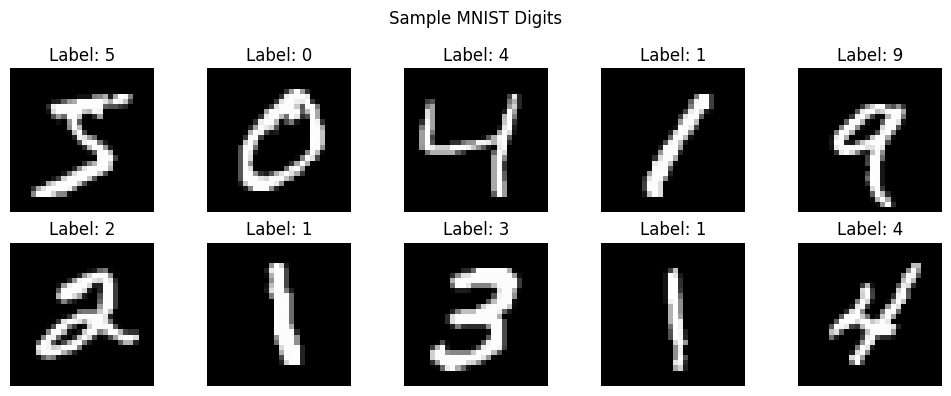

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_dataset.data[i].numpy(), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.show()

## 3. One-Hot Encode Labels

In [4]:
enc = OneHotEncoder(sparse_output=False)
Y_train = enc.fit_transform(y_train.reshape(-1, 1))
Y_test  = enc.transform(y_test.reshape(-1, 1))

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Y_train shape: {Y_train.shape}")

Train: 60000 | Test: 10000
Y_train shape: (60000, 10)


## 4. Neural Network from Scratch

**Architecture:** `784 → 128 (ReLU) → 10 (Softmax)`

In [5]:
np.random.seed(42)

# He initialization
W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
b1 = np.zeros((1, 128))
W2 = np.random.randn(128, 10) * np.sqrt(2 / 128)
b2 = np.zeros((1, 10))

def relu(z):    return np.maximum(0, z)
def relu_d(z):  return (z > 0).astype(float)
def softmax(z): e = np.exp(z - z.max(axis=1, keepdims=True)); return e / e.sum(axis=1, keepdims=True)

# Hyperparameters
lr         = 0.1
epochs     = 500
batch_size = 256
losses     = []
n          = X_train.shape[0]

for epoch in range(epochs):
    idx        = np.random.permutation(n)
    epoch_loss = 0.0
    batches    = 0

    for start in range(0, n, batch_size):
        xb = X_train[idx[start:start + batch_size]]
        yb = Y_train[idx[start:start + batch_size]]

        # Forward
        Z1 = xb @ W1 + b1;  A1 = relu(Z1)
        Z2 = A1 @ W2 + b2;  A2 = softmax(Z2)

        # Cross-entropy loss
        loss = -np.mean(np.sum(yb * np.log(A2 + 1e-9), axis=1))
        epoch_loss += loss
        batches    += 1

        # Backward
        dZ2 = (A2 - yb) / len(xb)
        dW2 = A1.T @ dZ2;  db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_d(Z1)
        dW1 = xb.T @ dZ1;  db1 = dZ1.sum(axis=0, keepdims=True)

        # Update
        W1 -= lr * dW1;  b1 -= lr * db1
        W2 -= lr * dW2;  b2 -= lr * db2

    losses.append(epoch_loss / batches)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d}/{epochs}  loss: {losses[-1]:.4f}")

print("Training done!")

Epoch  100/500  loss: 0.0145
Epoch  200/500  loss: 0.0043
Epoch  300/500  loss: 0.0022
Epoch  400/500  loss: 0.0014
Epoch  500/500  loss: 0.0010
Training done!


## 5. Loss Curve

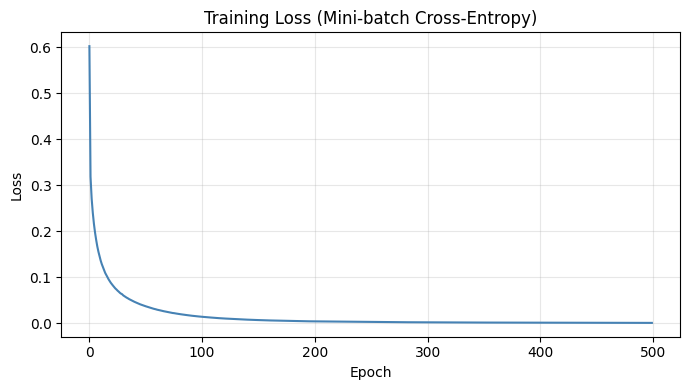

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(losses, color='steelblue')
plt.title('Training Loss (Mini-batch Cross-Entropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluate on Test Set

In [7]:
A1_test = relu(X_test @ W1 + b1)
A2_test = softmax(A1_test @ W2 + b2)
y_pred  = np.argmax(A2_test, axis=1)
acc     = np.mean(y_pred == y_test)
print(f"Test Accuracy: {acc:.2%}  ({int(acc * len(y_test))}/{len(y_test)} correct)")

Test Accuracy: 97.88%  (9788/10000 correct)


## 7. Predict on Sample Test Images

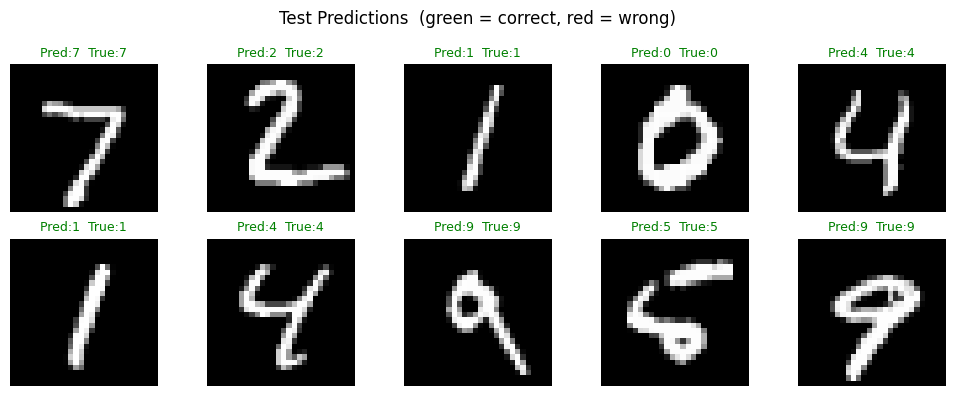

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f'Pred:{y_pred[i]}  True:{y_test[i]}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Test Predictions  (green = correct, red = wrong)')
plt.tight_layout()
plt.show()

## 8. Confusion Matrix

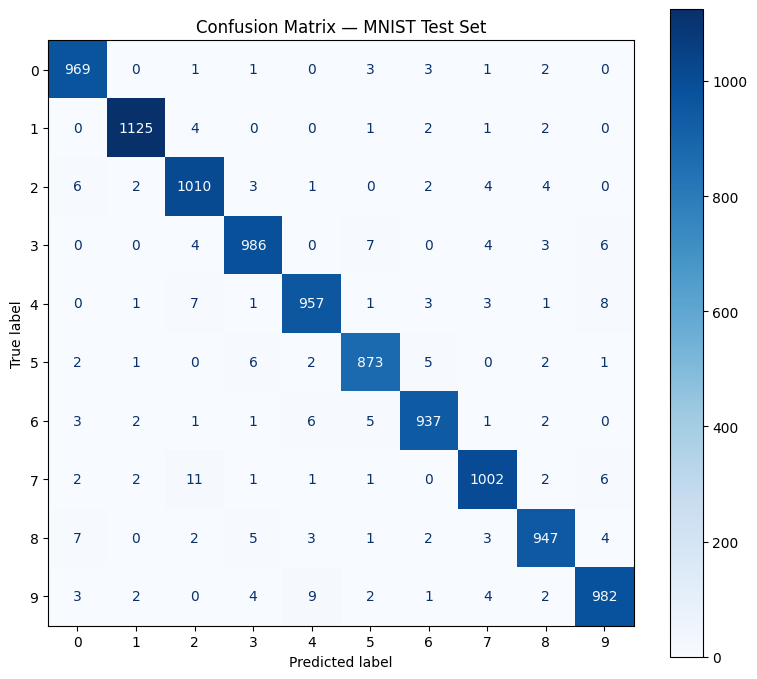

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — MNIST Test Set')
plt.tight_layout()
plt.show()